#MULTI AGENTIC SYSTEMS
---

##0.REFERENCE AND CONTEXT

**Introduction**

Modern artificial intelligence is increasingly moving beyond individual models toward coordinated systems of specialized agents. Traditional machine learning systems typically consist of a single model producing a single answer. However, many real-world decisions require multiple perspectives, competing objectives, governance oversight, and structured deliberation.

This challenge is particularly evident in finance. Investment decisions are rarely made by a single individual. Instead, organizations often rely on committees composed of economists, portfolio managers, risk specialists, compliance officers, and governance experts. Each participant contributes a different perspective, and final decisions emerge through discussion, disagreement, negotiation, and consensus.

Multi-Agent Systems bring this organizational structure into artificial intelligence. Rather than relying on a single reasoning process, a collection of specialized agents collaborate to solve a problem. Each agent possesses unique objectives, expertise, and evaluation criteria. The interaction among these agents creates a form of collective intelligence that can often outperform isolated decision-making.

In this notebook, students will build a synthetic AI Investment Committee using GPT-5.2. The committee consists of five agents: a Macroeconomist, a Risk Manager, a Portfolio Manager, a Governance Officer, and a Chairperson. Each agent evaluates the same investment question from a different perspective. Their opinions are collected, compared, and synthesized into a committee recommendation.

The notebook introduces key concepts including specialization, role-based reasoning, debate, voting, consensus formation, and governance. Students will observe how different objectives naturally generate different recommendations and how collective decision-making emerges from the interaction of multiple agents.

This chapter serves as an important bridge between reasoning systems and autonomous organizations. Later chapters will expand these ideas into advanced reasoning architectures and fully agentic AI systems capable of complex planning and decision-making.

By the end of this notebook, students will understand why many advanced AI architectures are increasingly organized as systems of cooperating agents rather than single monolithic models.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, creates project folders, loads required libraries, and initializes the GPT-5.2 client.

In [1]:
# CELL 1
# Environment Setup

!pip -q install openai

import json
import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path(
    "/content/chapter18_multi_agent"
)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime(
    "run_%Y%m%d_%H%M%S_utc"
)

print("Run ID:", RUN_ID)

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

MODEL_NAME = "gpt-5.2"

print("Model:", MODEL_NAME)

Run ID: run_20260606_155444_utc
Model: gpt-5.2


##2.THE INVESTMENT COMMITTEE

**Explanation for Cell 2**

This cell defines the investment committee question that will be evaluated by all agents.

In [2]:
# CELL 2
# Committee Question

committee_question = """
Should a pension fund increase
its allocation to private credit
over the next three years?
"""

print(
    committee_question
)


Should a pension fund increase
its allocation to private credit
over the next three years?



##3.THE MACROECONOMIST AGENT

**Explanation for Cell 3**

This cell creates the Macroeconomist Agent. The agent focuses on inflation, growth, interest rates, and economic conditions.

In [3]:
# CELL 3
# Macroeconomist Agent

macro_prompt = f"""
You are a Macroeconomist.

Focus on:

- Inflation
- Growth
- Interest Rates
- Business Cycles

Question:

{committee_question}

Return JSON:

{{
  "agent":"Macroeconomist",
  "position":"Support|Neutral|Oppose",
  "rationale":"..."
}}
"""

macro_response = client.responses.create(
    model=MODEL_NAME,
    input=macro_prompt
)

macro_opinion = macro_response.output_text

print(macro_opinion)

{
  "agent": "Macroeconomist",
  "position": "Support",
  "rationale": "From a macro perspective over the next three years, the case leans toward increasing private credit allocation, with sizing discipline. Inflation is likely to remain above the pre-2020 norm and more volatile, keeping nominal cash rates and credit spreads structurally higher than the 2010s. That environment improves carry for floating-rate private credit and reduces duration risk versus long fixed-rate public bonds. Growth is expected to be moderate and uneven (late-cycle dynamics in many developed economies, with periodic slowdowns rather than a deep, prolonged boom), which historically supports lender-friendly structures—provided underwriting is conservative. Interest rates are likely to be ‘higher for longer’ relative to the past decade, but with a growing probability of rate cuts if disinflation continues or recession risks rise; private credit’s floating-rate exposure benefits early in the period, while downsid

##4.THE RISK MANAGEMENT AGENT

**Explanation for Cell 4**

This cell creates the Risk Manager Agent. The agent evaluates volatility, liquidity, downside risk, and portfolio resilience.

In [4]:
# CELL 4
# Risk Manager Agent

risk_prompt = f"""
You are a Risk Manager.

Focus on:

- Liquidity
- Downside Risk
- Stress Scenarios
- Volatility

Question:

{committee_question}

Return JSON:

{{
  "agent":"Risk Manager",
  "position":"Support|Neutral|Oppose",
  "rationale":"..."
}}
"""

risk_response = client.responses.create(
    model=MODEL_NAME,
    input=risk_prompt
)

risk_opinion = risk_response.output_text

print(risk_opinion)

{
  "agent": "Risk Manager",
  "position": "Neutral",
  "rationale": "From a risk-management lens, a blanket increase in private credit over the next three years is not universally advisable; it can be prudent only if the fund’s liquidity profile, downside protections, and stress resilience are demonstrably sufficient. Liquidity is the primary constraint: private credit is typically multi-year locked, slow to reprice, and can experience delayed cash flows (extensions, payment-in-kind, workout periods). This can impair the ability to meet benefit payments or rebalance in drawdowns; the fund should size any increase to remain within a clearly defined liquidity budget (e.g., sufficient liquid assets and committed credit lines to cover stressed net outflows and capital calls without forced sales). Downside risk is elevated in late-cycle/slowdown conditions: defaults and restructurings tend to rise with a lag, recovery rates can be uncertain, and covenant quality may weaken in competitive l

##5.THE PORTFOLIO MANAGEMENT AGENT

**Explanation for Cell 5**

This cell creates the Portfolio Manager Agent. The agent focuses on returns, diversification, and portfolio efficiency.

In [5]:
# CELL 5
# Portfolio Manager Agent

portfolio_prompt = f"""
You are a Portfolio Manager.

Focus on:

- Expected Return
- Diversification
- Portfolio Efficiency
- Long-Term Allocation

Question:

{committee_question}

Return JSON:

{{
  "agent":"Portfolio Manager",
  "position":"Support|Neutral|Oppose",
  "rationale":"..."
}}
"""

portfolio_response = client.responses.create(
    model=MODEL_NAME,
    input=portfolio_prompt
)

portfolio_opinion = portfolio_response.output_text

print(portfolio_opinion)

{
  "agent": "Portfolio Manager",
  "position": "Support",
  "rationale": "A measured increase in private credit allocation over the next three years is warranted, provided pacing, manager selection, and liquidity budgets are tightly controlled. Expected returns remain attractive versus public IG/HY due to structural illiquidity and complexity premia, stronger lender protections (covenants, collateral), and the ability to negotiate pricing in less efficient markets—particularly in senior secured direct lending. From a diversification standpoint, private credit can reduce reliance on public rate/beta exposure and offer differentiated sources of income, especially when combined with a diversified mix across sponsor-backed, asset-based, opportunistic/distressed, and specialty finance. Portfolio efficiency can improve if private credit is used as a partial substitute for public credit and some equity risk: its risk-adjusted return potential and downside mitigation (seniority, collateral, t

##6.THE GOVERNANCE AGENT

**Explanation for Cell 6**

This cell creates the Governance Agent. The agent evaluates policy, compliance, fiduciary responsibility, and organizational constraints.

In [6]:
# CELL 6
# Governance Agent

governance_prompt = f"""
You are a Governance Officer.

Focus on:

- Governance
- Compliance
- Fiduciary Duty
- Policy Constraints

Question:

{committee_question}

Return JSON:

{{
  "agent":"Governance Officer",
  "position":"Support|Neutral|Oppose",
  "rationale":"..."
}}
"""

governance_response = client.responses.create(
    model=MODEL_NAME,
    input=governance_prompt
)

governance_opinion = governance_response.output_text

print(governance_opinion)

{
  "agent": "Governance Officer",
  "position": "Neutral",
  "rationale": "A pension fund should not pre-commit to increasing its private credit allocation over the next three years without first demonstrating that doing so is consistent with its fiduciary duties, investment policy constraints, and governance capacity. From a governance and compliance perspective, private credit can be permissible and potentially beneficial (e.g., diversification, income), but it introduces heightened risks and oversight requirements: limited transparency, illiquidity, valuation subjectivity, complex fee structures, lender-control provisions, use of leverage/subscription lines, and manager-specific operational and legal risks. A prudent approach is to assess: (1) alignment with the Statement of Investment Principles/Investment Policy Statement, including permitted asset classes, concentration limits, liquidity budget, and risk limits; (2) impact on the fund’s ability to pay benefits under stressed con

##7.THE CHAIRPERSON AGENT

**Explanation for Cell 7**

This cell creates the Chairperson Agent. The Chairperson reviews all committee opinions and prepares a preliminary synthesis.

In [7]:
# CELL 7
# Chairperson Agent

committee_material = f"""

MACROECONOMIST

{macro_opinion}

RISK MANAGER

{risk_opinion}

PORTFOLIO MANAGER

{portfolio_opinion}

GOVERNANCE OFFICER

{governance_opinion}

"""

chair_prompt = f"""
You are the Chairperson.

Review all committee opinions.

Question:

{committee_question}

Committee Inputs:

{committee_material}

Return JSON:

{{
  "committee_summary":"...",
  "areas_of_agreement":"...",
  "areas_of_disagreement":"..."
}}
"""

chair_response = client.responses.create(
    model=MODEL_NAME,
    input=chair_prompt
)

chair_summary = chair_response.output_text

print(chair_summary)

{
  "committee_summary": "The committee leans toward a measured, conditional increase in private credit over the next three years, rather than a blanket or rapid expansion. The Macroeconomist and Portfolio Manager support increasing allocation to capture elevated carry and illiquidity/complexity premia in a higher-rate, more volatile regime, with emphasis on senior secured and conservative underwriting. The Risk Manager and Governance Officer are neutral, stressing that any increase must be contingent on demonstrated liquidity resilience, realistic stress testing (including recession/default clusters and delayed distributions), and sufficient governance capacity for due diligence, valuation oversight, and ongoing monitoring. Overall recommendation: proceed only with disciplined pacing, strong downside protections, and formal policy/governance checks.",
  "areas_of_agreement": "All members agree that: (1) any increase should be gradual/phased (pacing and vintage diversification), not an

##8.THE COMMITTEE VOTING

**Explanation for Cell 8**

This cell performs committee voting and produces a structured tally of positions.

In [8]:
# CELL 8
# Committee Voting

all_opinions = {
    "macro": macro_opinion,
    "risk": risk_opinion,
    "portfolio": portfolio_opinion,
    "governance": governance_opinion
}

voting_prompt = f"""
Analyze these committee opinions.

Count:

Support
Neutral
Oppose

Return JSON:

{{
  "support":0,
  "neutral":0,
  "oppose":0,
  "majority_position":"..."
}}

Opinions:

{json.dumps(all_opinions, indent=2)}
"""

vote_response = client.responses.create(
    model=MODEL_NAME,
    input=voting_prompt
)

vote_results = vote_response.output_text

print(vote_results)

{
  "support": 2,
  "neutral": 2,
  "oppose": 0,
  "majority_position": "No majority (tie between Support and Neutral at 2 each)"
}


##9.THE COMMITTEE REPORT

**Explanation for Cell 9**

This cell creates the final committee report containing the official recommendation.

In [9]:
# CELL 9
# Final Committee Report

report_prompt = f"""
Create a final committee report.

Question:

{committee_question}

Committee Opinions:

{committee_material}

Chairperson Summary:

{chair_summary}

Voting Results:

{vote_results}

Return a professional
investment committee report.
"""

report_response = client.responses.create(
    model=MODEL_NAME,
    input=report_prompt
)

committee_report = report_response.output_text

report_path = (
    ARTIFACT_DIR /
    "committee_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        committee_report
    )

print(committee_report)
print("\nSaved:", report_path)

# Investment Committee Final Report  
**Question:** Should the pension fund increase its allocation to private credit over the next three years?  
**Date:** 6 June 2026  

## 1. Executive Decision
**Committee conclusion:** *Proceed with a measured, conditional increase* in private credit over the next three years **only if** defined liquidity, risk, and governance preconditions are met and evidenced through formal analysis and approvals.  

**Vote:** Support 2 | Neutral 2 | Oppose 0 → **No majority (tie).**  
**Chair’s determination:** Given the tie, the committee adopts a **conditional implementation plan** rather than a blanket increase or a deferral. Any allocation change is **gated** by completion of required stress tests, liquidity budgeting, and governance readiness checks.

---

## 2. Rationale (Committee Synthesis)

### 2.1 Strategic Case for a Gradual Increase (Supporting Views)
- **Macro/market environment:** The committee expects a regime of **structurally higher and more vo

##10.THE WORKFLOW

**Explanation for Cell 10**

This cell visualizes the committee structure and interaction workflow.

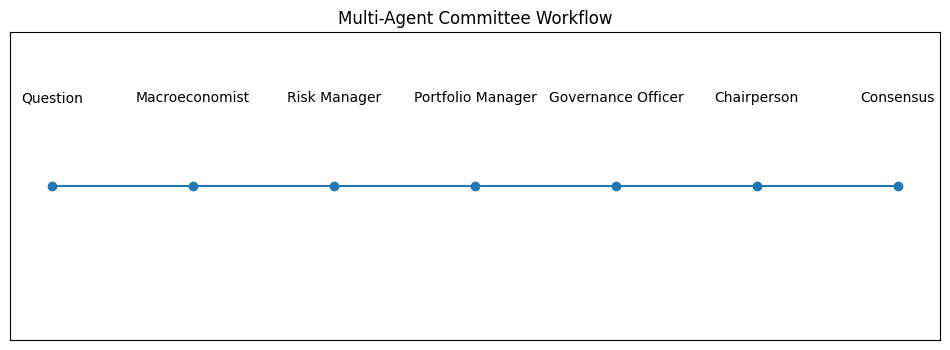

In [10]:
# CELL 10
# Agent Interaction Visualization

agents = [

    "Question",

    "Macroeconomist",

    "Risk Manager",

    "Portfolio Manager",

    "Governance Officer",

    "Chairperson",

    "Consensus"

]

x = np.arange(
    len(agents)
)

y = np.ones(
    len(agents)
)

plt.figure(
    figsize=(12,4)
)

plt.plot(
    x,
    y,
    marker="o"
)

for i, label in enumerate(agents):

    plt.text(
        x[i],
        y[i] + 0.03,
        label,
        ha="center"
    )

plt.yticks([])
plt.xticks([])
plt.title(
    "Multi-Agent Committee Workflow"
)

plt.show()

##11.SUMMARY AND EXPLANATION

In [11]:
# CELL 11
# GPT-5.2 Reflection

summary = {

    "question":
        committee_question,

    "agents": [

        "Macroeconomist",
        "Risk Manager",
        "Portfolio Manager",
        "Governance Officer",
        "Chairperson"

    ],

    "workflow":
        "multi-agent committee",

    "report_location":
        str(report_path)
}

reflection_prompt = f"""
Analyze this multi-agent system.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""

reflection_response = client.responses.create(
    model=MODEL_NAME,
    input=reflection_prompt
)

print(
    reflection_response.output_text
)

{
  "system_type": "multi-agent committee",
  "question": "Should a pension fund increase its allocation to private credit over the next three years?",
  "agents": [
    {
      "name": "Macroeconomist",
      "primary_role": "Assess macro/market regime implications for private credit (growth, inflation, rates, liquidity, default cycle).",
      "typical_inputs": [
        "GDP/inflation outlook",
        "Policy rate path/term premium",
        "Credit cycle indicators (defaults, leverage, underwriting standards)",
        "Bank lending standards and disintermediation trends",
        "Liquidity conditions and refinancing wall"
      ],
      "key_outputs": [
        "Base/bull/bear macro scenarios",
        "Implications for spreads, default rates, and recovery",
        "Timing/pace recommendation for allocation changes"
      ],
      "main_risks_flagged": [
        "Late-cycle credit deterioration",
        "Refinancing risk in higher-rate regime",
        "Liquidity shocks wideni

##12.CONCLUSION

**Conclusion**

This notebook introduced Multi-Agent Systems, one of the most important architectural developments in modern artificial intelligence. Rather than relying on a single model to evaluate a problem, the system distributed responsibility across multiple specialized agents. Each agent contributed unique expertise and evaluated the same question through a different analytical lens.

Students observed how specialization naturally creates diversity of opinion. The Macroeconomist focused on economic conditions, the Risk Manager emphasized downside protection, the Portfolio Manager evaluated investment opportunities, and the Governance Officer considered fiduciary responsibilities and organizational constraints. The Chairperson then synthesized these perspectives into a coherent recommendation.

This process mirrors many real-world organizational structures. Investment committees, corporate boards, regulatory agencies, and strategic planning teams often rely on multiple experts with distinct responsibilities. Multi-Agent Systems replicate this structure computationally, creating a form of collective intelligence that can improve robustness and transparency.

The notebook also introduced several key concepts including role specialization, committee deliberation, voting, consensus formation, and governance. These mechanisms help AI systems move beyond simple prediction toward structured decision-making processes.

An important lesson from this chapter is that intelligence can emerge not only from increasingly powerful models but also from improved coordination among specialized agents. Many advanced AI systems now focus on orchestrating multiple reasoning processes rather than simply scaling individual models.

This chapter serves as the foundation for the final stages of the curriculum. In the next chapter, students will explore Reasoning Architectures, including Chain of Thought, Tree of Thought, Graph of Thought, Multi-Timeline Reasoning, and Reasoning Molecules. These architectures provide the internal cognitive structures that agents use when solving complex problems.

Ultimately, Multi-Agent Systems represent a major step toward autonomous organizations and AI governance frameworks. They demonstrate how collective reasoning can emerge from coordinated interactions among specialized intelligent entities.